In [ ]:
#We will utilize the yfinance library to retrieve historical volatility data and implement the GARCH 
#(Generalized Autoregressive Conditional Heteroskedasticity) model to estimate and forecast volatility.
#Volatility is a crucial aspect of financial markets as it measures the degree of variation in the price of a financial instrument over time. 
#Accurate volatility forecasting can assist traders and investors in making informed decisions and managing risk effectively.

In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
%matplotlib inline
import seaborn as sns
from datetime import datetime

In [2]:
import yfinance as yf
# Retrieve historical volatility data for SPY
stock = yf.Ticker("SPY")
#volatility_data = stock.history(period="max")
# Fetch last 5 years instead of max
volatility_data = stock.history(period="5y")

YFRateLimitError: Too Many Requests. Rate limited. Try after a while.

In [3]:
from alpha_vantage.timeseries import TimeSeries

# Set your API key
api_key = "YOUR_ALPHA_VANTAGE_KEY"

# Create TimeSeries object
ts = TimeSeries(key=api_key, output_format="pandas")

# Get daily stock data for Goldman Sachs (SPY)
volatility_data, meta_data = ts.get_daily(symbol="SPY", outputsize="full")

# Display last few rows of the DataFrame
print(volatility_data.tail())

             1. open   2. high    3. low  4. close  5. volume
date                                                         
1999-11-05  138.6250  139.1093  136.7812  137.8750  7431500.0
1999-11-04  136.7500  137.3593  135.7656  136.5312  7907500.0
1999-11-03  136.0000  136.3750  135.1250  135.5000  7222300.0
1999-11-02  135.9687  137.2500  134.5937  134.5937  6516900.0
1999-11-01  136.5000  137.0000  135.5625  135.5625  4006500.0


In [ ]:
#The history method retrieves historical price data for the specified stock symbol. 
#By setting the period parameter to "max", we retrieve the entire available history of the stock.

In [4]:
volatility_data.head()

,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2025-03-14,556.11,563.830,551.4917,562.81,62660321.0
2025-03-13,558.49,559.105,549.6800,551.42,74079414.0
2025-03-12,562.17,563.110,553.6900,558.87,69588167.0
2025-03-11,559.40,564.020,552.0200,555.92,88102109.0
2025-03-10,567.59,569.540,555.5900,560.58,97084529.0


In [7]:
#The columns represent:
#Open: Opening price of the stock
#High: Highest price during the trading day
#Low: Lowest price during the trading day
#Close: Closing price of the stock
#Volume: Number of shares traded

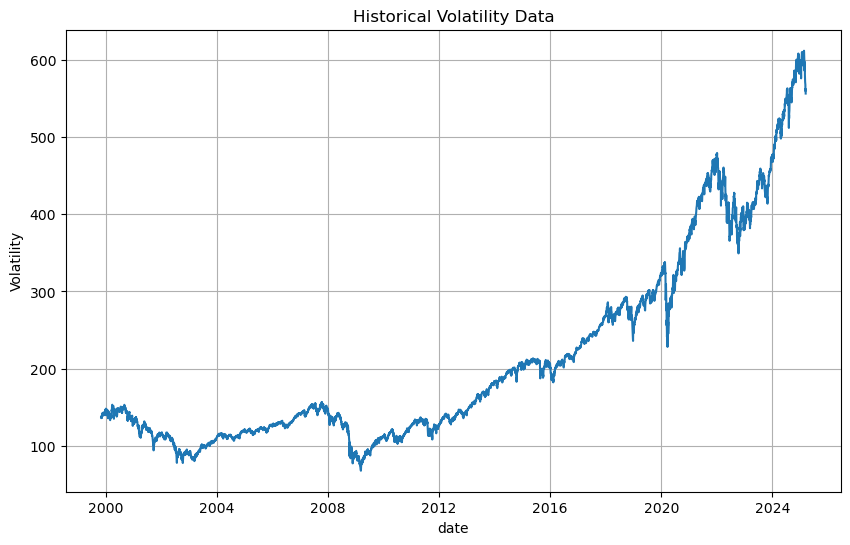

In [5]:
# Plot the historical volatility data
plt.figure(figsize=(10, 6))
plt.plot(volatility_data.index, volatility_data["1. open"])
plt.xlabel("date")
plt.ylabel("Volatility")
plt.title("Historical Volatility Data")
plt.grid(True)

plt.show()

In [ ]:
#The line plot provides a visual representation of the volatility data over time. 
#It helps us identify any trends, seasonality, or outliers present in the data.

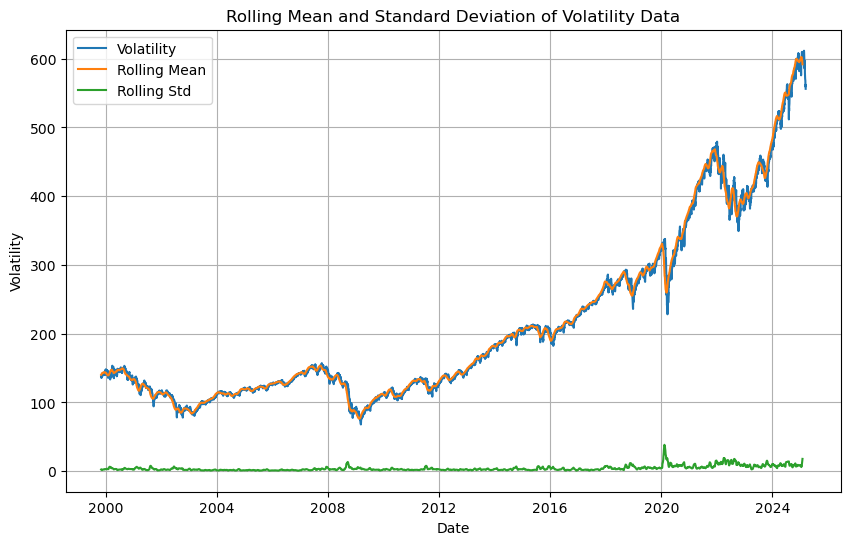

In [6]:
# Calculate the rolling mean and standard deviation
rolling_mean = volatility_data["1. open"].rolling(window=30).mean()
rolling_std = volatility_data["1. open"].rolling(window=30).std()

# Plot the rolling mean and standard deviation
plt.figure(figsize=(10, 6))
plt.plot(volatility_data.index, volatility_data["1. open"], label="Volatility")
plt.plot(rolling_mean.index, rolling_mean, label="Rolling Mean")
plt.plot(rolling_std.index, rolling_std, label="Rolling Std")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Rolling Mean and Standard Deviation of Volatility Data")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#The rolling mean and standard deviation provide insights into the long-term trends and volatility clustering in the data. 
#They help us identify periods of high and low volatility.

In [10]:
!pip install arch

Defaulting to user installation because normal site-packages is not writeable


In [7]:
from arch import arch_model

In [8]:
# Calculate log returns
returns = np.log(volatility_data["1. open"]).diff().dropna()

In [ ]:
#The log returns represent the percentage change in the volatility data from one period to the next. 
# log returns Stabilizes variance: Unlike raw percentage returns, log returns make time series more stationary.
#They are commonly used in financial analysis as they provide a more meaningful representation of the data.

In [9]:
# Fit an ARCH(1) model to the returns data
model_arch = arch_model(returns, vol='ARCH', p=1)  # p=1 for ARCH(1)
model_fit_arch = model_arch.fit()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 1652001936405.451
Iteration:      2,   Func. Count:     17,   Neg. LLF: 967653169581.9585
Iteration:      3,   Func. Count:     29,   Neg. LLF: 3427988929.877383
Iteration:      4,   Func. Count:     40,   Neg. LLF: -19810.889960863504
Optimization terminated successfully    (Exit mode 0)
            Current function value: -19810.889959902343
            Iterations: 8
            Function evaluations: 40
            Gradient evaluations: 4


C:\Users\Tanvi.Koyande\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001434. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [10]:
# Output the model summary
print(model_fit_arch.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                1. open   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                19810.9
Distribution:                  Normal   AIC:                          -39615.8
Method:            Maximum Likelihood   BIC:                          -39595.5
                                        No. Observations:                 6380
Date:                Mon, Mar 17 2025   Df Residuals:                     6379
Time:                        09:50:09   Df Model:                            1
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -4.8537e-04  1.328e-04     -3.654  2.5

In [11]:
volatility_arch = model_fit_arch.conditional_volatility

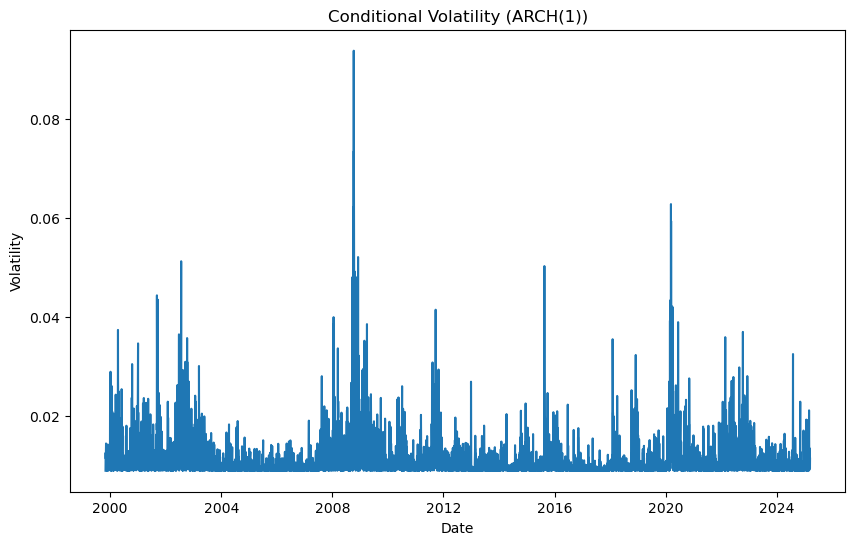

In [12]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility_arch)
plt.title('Conditional Volatility (ARCH(1))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

In [13]:
# Calculate the mean absolute error (MAE)
mae = np.mean(np.abs(volatility_arch - returns))
print("Mean Absolute Error (MAE):", mae)

# Calculate the root mean squared error (RMSE)
rmse = np.sqrt(np.mean((volatility_arch - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.01325837385531854
Root Mean Squared Error (RMSE): 0.01669513337934116


In [ ]:
#GARCH (Generalized Autoregressive Conditional Heteroskedasticity) model. 
#A GARCH model is an extension of the ARCH model and is typically more flexible. 
#It includes both past squared residuals (like ARCH) and past conditional variances (volatility) in the model.

In [14]:
# Fit the GARCH(1, 1) model
model = arch_model(returns, vol="Garch", p=1, q=1)
results = model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 439458700278.79767
Iteration:      2,   Func. Count:     19,   Neg. LLF: -20650.61899922482
Inequality constraints incompatible    (Exit mode 4)
            Current function value: -20650.619036266675
            Iterations: 2
            Function evaluations: 19
            Gradient evaluations: 2


C:\Users\Tanvi.Koyande\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001434. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\Tanvi.Koyande\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


In [15]:
#we are fitting a GARCH(1, 1) model, which includes one lag of both the returns and the conditional variance

In [15]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                1. open   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                20650.6
Distribution:                  Normal   AIC:                          -41293.2
Method:            Maximum Likelihood   BIC:                          -41266.2
                                        No. Observations:                 6380
Date:                Mon, Mar 17 2025   Df Residuals:                     6379
Time:                        09:50:33   Df Model:                            1
                                   Mean Model                                  
===============================================================================
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -6.2496e-04  9.198e-05     -6.795  1.087e-11 [-8.052e-04,-4.447e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      2.8680e-06  1.837e-13  1.561e+07      0.000 [2.868e-06,2.868e-06]
alpha[1]       0.1000  3.380e-04    295.868      0.000   [9.934e-02,  0.101]
beta[1]        0.8800  2.560e-03    343.710      0.000     [  0.875,  0.885]
============================================================================

Covariance estimator: robust
WARNING: The optimizer did not indicate successful convergence. The message was Inequality constraints incompatible.
See convergence_flag.

"""

In [ ]:
#Once we have fitted the GARCH model, we can estimate and forecast the volatility. 
#The estimated volatility represents the conditional variance of the log returns, while the forecasted volatility provides future volatility predictions.

In [16]:
# Estimate the volatility
volatility = results.conditional_volatility

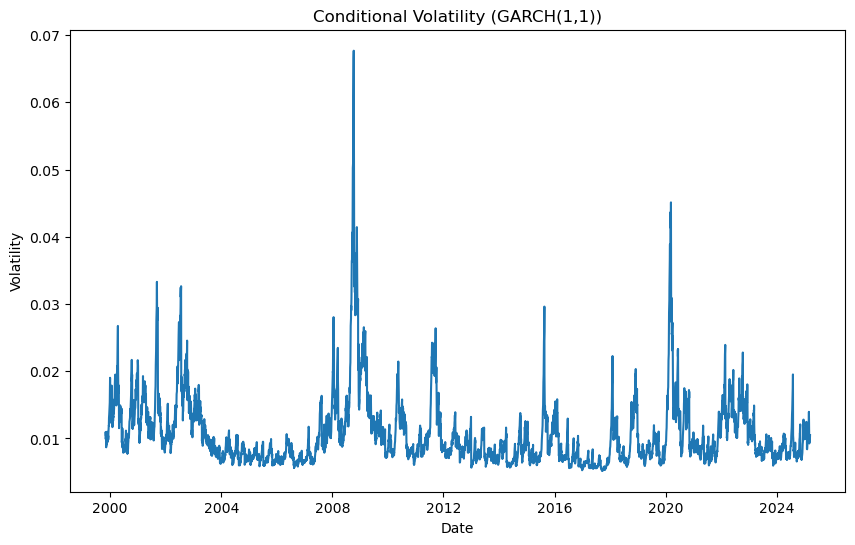

In [17]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility)
plt.title('Conditional Volatility (GARCH(1,1))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

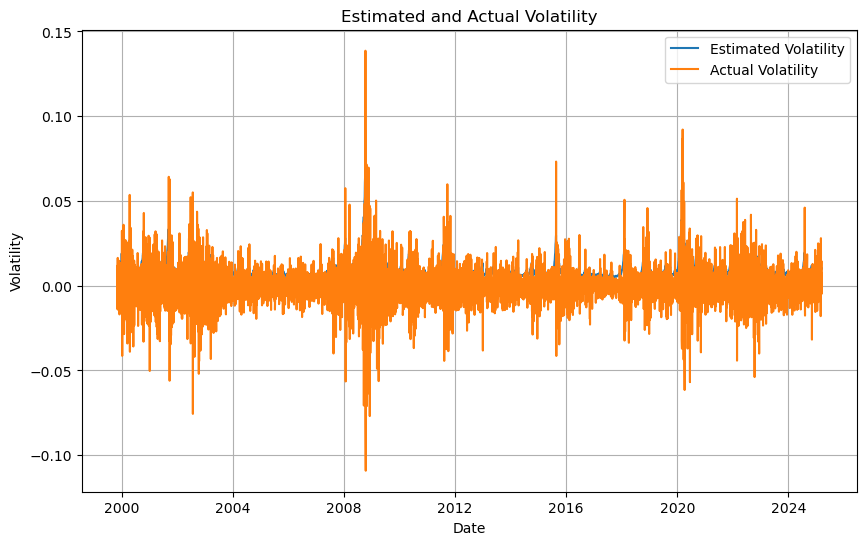

In [18]:
# Plot the estimated and actual volatility
plt.figure(figsize=(10, 6))
plt.plot(volatility.index, volatility, label="Estimated Volatility")
plt.plot(returns.index, returns, label="Actual Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Estimated and Actual Volatility")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#The plot shows the estimated volatility (conditional variance) and the actual volatility (log returns) over time. 
#It helps us assess the accuracy of the volatility estimates

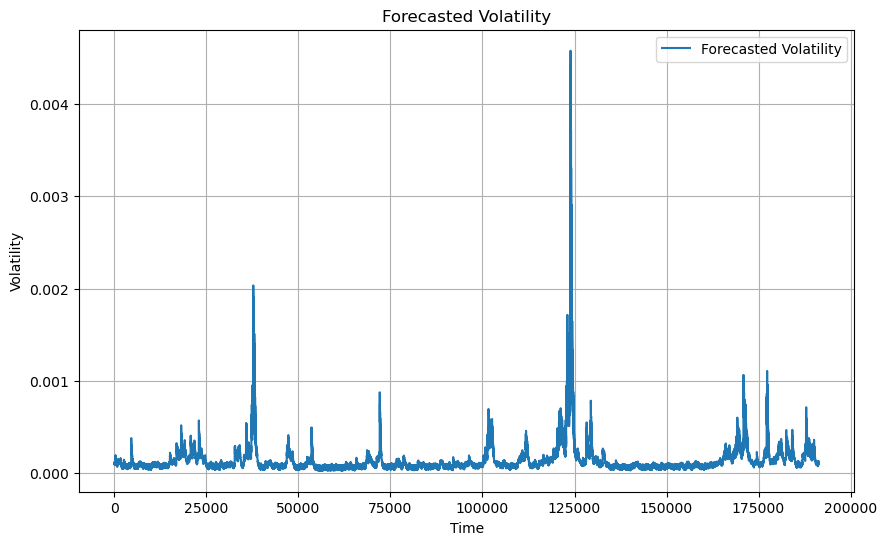

In [19]:
# Forecast the volatility
forecast = results.forecast(start=0, horizon=30)
forecast_volatility = forecast.variance.dropna().values.flatten()

# Plot the forecasted volatility
plt.figure(figsize=(10, 6))
plt.plot(forecast_volatility, label="Forecasted Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.title("Forecasted Volatility")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#The plot displays the forecasted volatility for the next 30 periods. 
#It provides insights into the expected future volatility based on the GARCH model.

In [20]:
# Calculate the mean absolute error (MAE)
mae = np.mean(np.abs(volatility - returns))
print("Mean Absolute Error (MAE):", mae)

# Calculate the root mean squared error (RMSE)
rmse = np.sqrt(np.mean((volatility - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.01259052576975306
Root Mean Squared Error (RMSE): 0.016523064558452816


In [ ]:
#The MAE and RMSE provide measures of the average and overall forecast errors, respectively. 
#Lower values indicate better model performance.

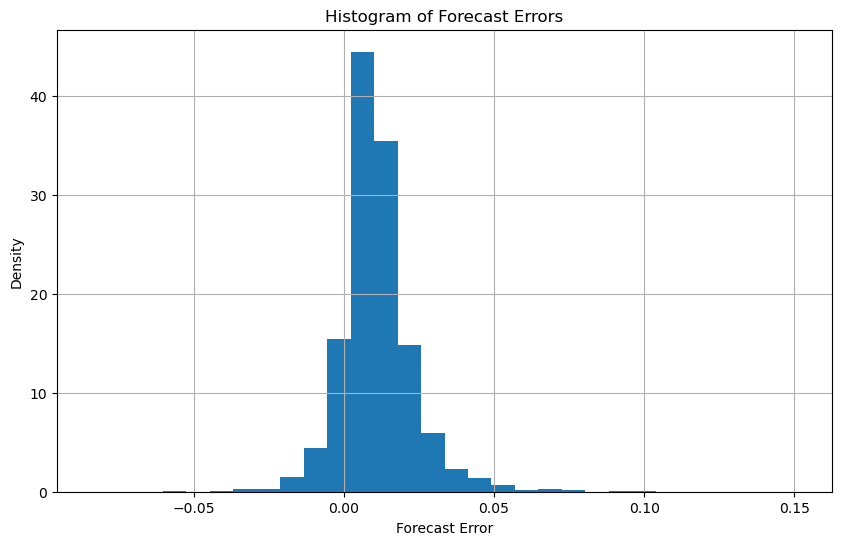

In [21]:
# Calculate the forecast errors
errors = volatility - returns

# Plot the histogram of forecast errors
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, density=True)
plt.xlabel("Forecast Error")
plt.ylabel("Density")
plt.title("Histogram of Forecast Errors")
plt.grid(True)

plt.show()

In [22]:
#The histogram provides insights into the distribution of forecast errors. 
#It helps us assess the accuracy and reliability of the volatility forecasts.

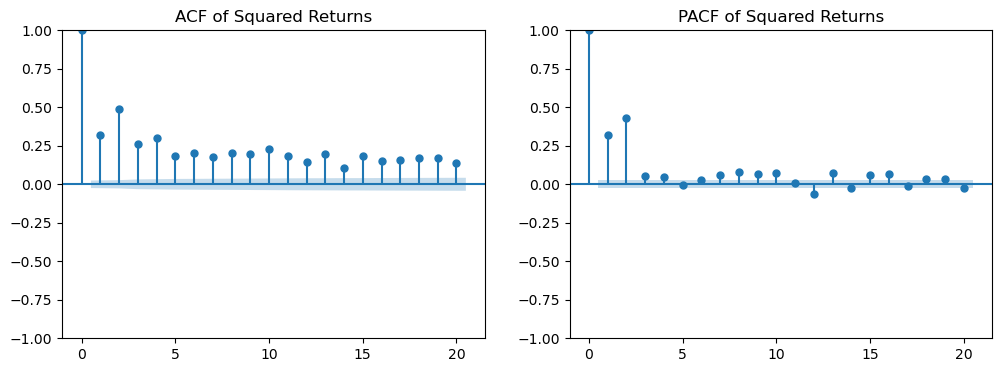

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF of squared returns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(returns**2, lags=20, ax=axes[0])
axes[0].set_title("ACF of Squared Returns")

plot_pacf(returns**2, lags=20, ax=axes[1])
axes[1].set_title("PACF of Squared Returns")

plt.show()

In [ ]:
#From your ACF and PACF plots of squared returns, we can determine the GARCH(p, q) parameters as follows:

#q (MA component in volatility - from ACF)
#The ACF plot shows significant spikes at lags 1, 2, and possibly 3 before tapering off.
#This suggests that q = 2  might be a good choice.

#p (AR component in volatility - from PACF)
#The PACF plot shows significant spikes at lags 1 and 2, after which it dies down.
#This suggests that p = 2 might be appropriate.
#Suggested Model: GARCH(2,2)

In [23]:
# Fit the GARCH(2, 2) model
model1 = arch_model(returns, vol="Garch", p=2, q=2)
results1 = model1.fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 9.32954085010061e+22
Iteration:      2,   Func. Count:     24,   Neg. LLF: 293095219742.9851
Iteration:      3,   Func. Count:     40,   Neg. LLF: 4.4043935506974835e+19
Iteration:      4,   Func. Count:     55,   Neg. LLF: 4.152044239636761e+17
Optimization terminated successfully    (Exit mode 0)
            Current function value: -20680.29057985693
            Iterations: 7
            Function evaluations: 63
            Gradient evaluations: 4


C:\Users\Tanvi.Koyande\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001434. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [25]:
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                1. open   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                20680.3
Distribution:                  Normal   AIC:                          -41348.6
Method:            Maximum Likelihood   BIC:                          -41308.0
                                        No. Observations:                 6380
Date:                Mon, Mar 17 2025   Df Residuals:                     6379
Time:                        09:52:17   Df Model:                            1
                                   Mean Model                                  
===============================================================================
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -5.9538e-04  1.011e-04     -5.890  3.870e-09 [-7.935e-04,-3.972e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      2.8680e-06  2.039e-11  1.407e+05      0.000 [2.868e-06,2.868e-06]
alpha[1]       0.1000  3.554e-02      2.813  4.902e-03   [3.033e-02,  0.170]
alpha[2]       0.1000  1.914e-02      5.225  1.746e-07   [6.249e-02,  0.138]
beta[1]        0.3900      0.315      1.237      0.216     [ -0.228,  1.008]
beta[2]        0.3900      0.295      1.323      0.186     [ -0.188,  0.968]
============================================================================

Covariance estimator: robust
"""

In [26]:
volatility1 = results1.conditional_volatility

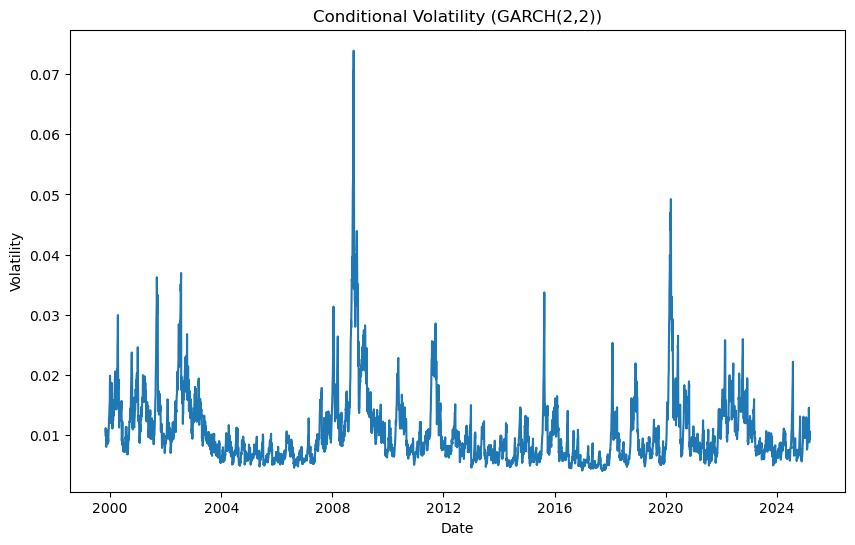

In [27]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility1)
plt.title('Conditional Volatility (GARCH(2,2))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

In [28]:
# Calculate the mean absolute error (MAE)
mae1 = np.mean(np.abs(volatility1 - returns))
print("Mean Absolute Error (MAE):", mae1)

# Calculate the root mean squared error (RMSE)
rmse1 = np.sqrt(np.mean((volatility1 - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse1)

Mean Absolute Error (MAE): 0.01232363725975
Root Mean Squared Error (RMSE): 0.016446220882173332


In [ ]:
#Comparing mae and rmse
#ARCH (1)
#Mean Absolute Error (MAE): 0.01325837385531854
#Root Mean Squared Error (RMSE): 0.01669513337934116

#GARCH(1,1)
#Mean Absolute Error (MAE): 0.01259052576975306
#Root Mean Squared Error (RMSE): 0.016523064558452816

#GARCH(2,2)
#Mean Absolute Error (MAE): 0.01232363725975
#Root Mean Squared Error (RMSE): 0.016446220882173332

